In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/neurosense_cleaned.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (37575, 361)
   eeg_feature_1  eeg_feature_2  eeg_feature_3  eeg_feature_4  eeg_feature_5  \
0      26.791522      24.062115      21.927618      19.697461      18.626858   
1      26.791101      24.061706      21.928215      19.697127      18.626882   
2      26.791650      24.062570      21.929218      19.696753      18.626936   
3      26.793695      24.063827      21.931248      19.696395      18.626931   
4      26.794138      24.064473      21.933663      19.696645      18.627109   

   eeg_feature_6  eeg_feature_7  eeg_feature_8  eeg_feature_9  eeg_feature_10  \
0      26.781416      24.090212      21.992052      19.634864       18.446852   
1      26.780972      24.089481      21.992834      19.634719       18.447054   
2      26.783116      24.090431      21.994368      19.634771       18.447366   
3      26.787306      24.092226      21.997363      19.634678       18.447735   
4      26.790289      24.093457      22.000899      19.635314       18.448518   

   .

In [2]:
X = df.drop(columns=["label", "subject", "session", "trial", "sample"])
X = X.select_dtypes(include=["number"])

y = df["label"]
groups = df["subject"]

print("Features:", X.shape)
print("Labels:", y.value_counts())

Features: (37575, 355)
Labels: label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64


In [4]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train subjects:", df.iloc[train_idx]["subject"].nunique())
print("Test subjects:", df.iloc[test_idx]["subject"].nunique())

Train shape: (30060, 355)
Test shape: (7515, 355)
Train subjects: 12
Test subjects: 3


In [5]:
dt_basic = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_basic.fit(X_train, y_train)

y_pred_basic = dt_basic.predict(X_test)

basic_results = {
    "Model": "Decision Tree Basic GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_basic),
    "Precision": precision_score(y_test, y_pred_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_basic, average="weighted"),
    "Best Parameters": "Default parameters, class_weight=balanced"
}

basic_results

{'Model': 'Decision Tree Basic GroupSplit 4-Class',
 'Accuracy': 0.31949434464404525,
 'Precision': 0.321485503340222,
 'Recall': 0.31949434464404525,
 'F1-score': 0.3173701257425337,
 'Best Parameters': 'Default parameters, class_weight=balanced'}

In [6]:
print(classification_report(y_test, y_pred_basic))

              precision    recall  f1-score   support

           0       0.35      0.40      0.37      1950
           1       0.25      0.28      0.27      1905
           2       0.36      0.36      0.36      1947
           3       0.32      0.22      0.26      1713

    accuracy                           0.32      7515
   macro avg       0.32      0.32      0.32      7515
weighted avg       0.32      0.32      0.32      7515



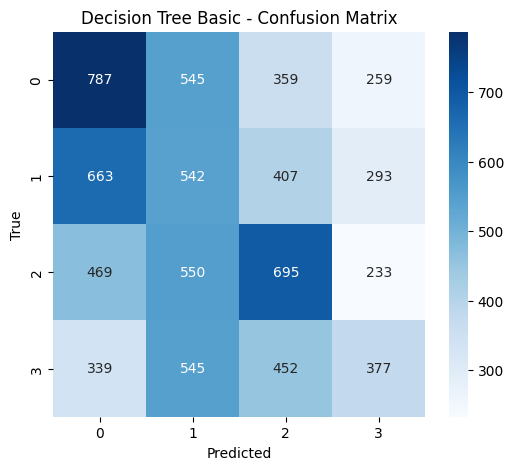

In [7]:
cm = confusion_matrix(y_test, y_pred_basic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Basic - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [8]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_dt.best_params_)

print("Best CV F1-score:")
print(grid_search_dt.best_score_)

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Best Parameters:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1-score:
0.2817509946257799


In [9]:
best_dt = grid_search_dt.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

tuned_results = {
    "Model": "Decision Tree + GridSearchCV GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average="weighted"),
    "Recall": recall_score(y_test, y_pred_tuned, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_tuned, average="weighted"),
    "Best Parameters": grid_search_dt.best_params_
}

tuned_results
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.41      0.33      0.37      1950
           1       0.23      0.21      0.22      1905
           2       0.36      0.46      0.40      1947
           3       0.39      0.39      0.39      1713

    accuracy                           0.35      7515
   macro avg       0.35      0.35      0.35      7515
weighted avg       0.35      0.35      0.35      7515



In [10]:
results_df = pd.DataFrame([basic_results, tuned_results])
results_df

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Decision Tree Basic GroupSplit 4-Class,0.319494,0.321486,0.319494,0.317370,"Default parameters, class_weight=balanced"
1,Decision Tree + GridSearchCV GroupSplit 4-Class,0.347572,0.348545,0.347572,0.345415,"{'class_weight': 'balanced', 'criterion': 'ent..."


In [11]:
comparison_df = pd.DataFrame([
    basic_results,
    tuned_results
])

comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score"]
]

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree Basic GroupSplit 4-Class,0.319494,0.321486,0.319494,0.317370
1,Decision Tree + GridSearchCV GroupSplit 4-Class,0.347572,0.348545,0.347572,0.345415


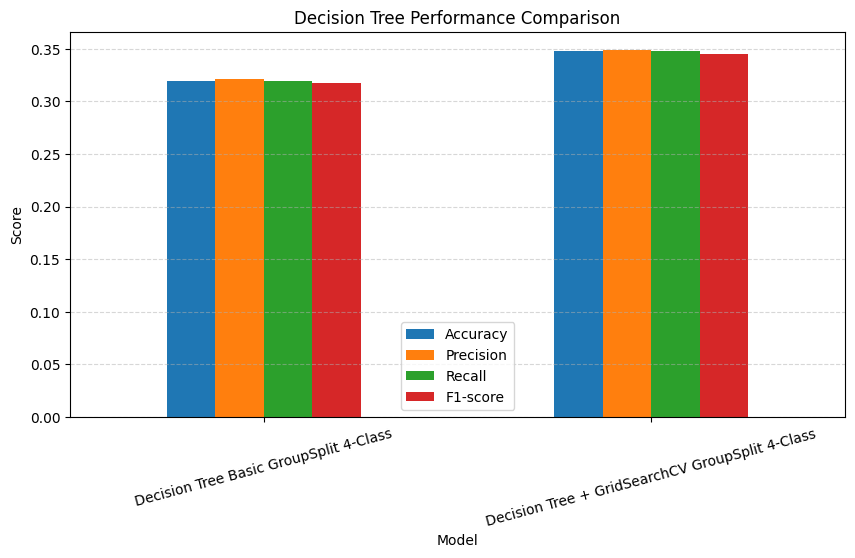

In [12]:
metrics_df = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

metrics_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Decision Tree Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

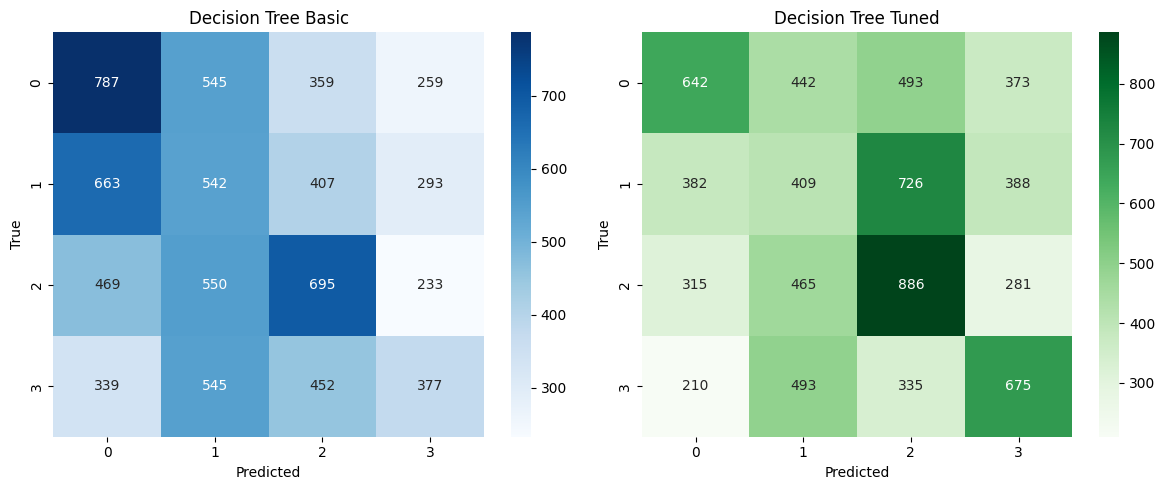

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_basic = confusion_matrix(y_test, y_pred_basic)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm_basic,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Decision Tree Basic")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Decision Tree Tuned")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [14]:
results_df.to_csv(
    "../results/tables/decision_tree_results.csv",
    index=False
)